# Lab 3: Contextual Bandit-Based News Article Recommendation System

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Niyati Singh 
**Roll Number:** U20230080 
**GitHub Branch:** niyati_u20230080

**Objective:** To implement a News Recommendation System using Contextual Multi-Armed Bandits (CMAB) to recommend news articles based on user categories.

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from rlcmab_sampler import sampler

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


ROLL_NUMBER = 80  

## Load Datasets

In [2]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(f"\nDataset Shapes:")
print(f"  • News articles: {news_df.shape}")
print(f"  • Training users: {train_users.shape}")
print(f"  • Test users: {test_users.shape}")


Dataset Shapes:
  • News articles: (209527, 6)
  • Training users: (2000, 33)
  • Test users: (2000, 32)


In [3]:
# Quick data inspection
print(f"\nNews Categories ({len(news_df['category'].unique())} total):")
print(news_df['category'].value_counts().head(10))

print(f"\nUser Label Distribution:")
print(train_users['label'].value_counts())


News Categories (42 total):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64

User Label Distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


In [5]:
#Checking for missing values
print("\nMissing Values Analysis:")
print(f"Training Users - Missing: {train_users.isnull().sum().sum()} values")
print(f"Test Users - Missing: {test_users.isnull().sum().sum()} values")
print(f"News Articles - Missing: {news_df.isnull().sum().sum()} values")


Missing Values Analysis:
Training Users - Missing: 698 values
Test Users - Missing: 679 values
News Articles - Missing: 57136 values


## 5.1 Data Pre-processing

In this section we:
- Handle missing values  
- Filter news articles for relevant categories (Entertainment, Education, Tech, Crime)  
- Encode categorical features  
- Prepare data for user classification

In [6]:
#Filtering Articles for target categories
target_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
news_df_filtered = news_df[news_df['category'].isin(target_categories)].copy()
news_df_filtered.reset_index(drop=True, inplace=True)

print(f"\nFiltered Articles: {news_df_filtered.shape[0]} articles")
print(f"\nCategory Distribution:")
for cat in target_categories:
    count = (news_df_filtered['category'] == cat).sum()
    print(f"  • {cat}: {count} articles")

#User Preprocessing
def preprocess_users(df, is_training=True):
    """Enhanced preprocessing with multiple strategies"""
    df_clean = df.copy()
    
    #Standardize labels
    if 'label' in df_clean.columns:
        df_clean['label'] = df_clean['label'].str.replace('user_', 'User', regex=False).str.capitalize()
    
    #Identify numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'label' in numeric_cols:
        numeric_cols.remove('label')
    
    #Handle missing values with mean imputation
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
    
    return df_clean


Filtered Articles: 24042 articles

Category Distribution:
  • ENTERTAINMENT: 17362 articles
  • EDUCATION: 1014 articles
  • TECH: 2104 articles
  • CRIME: 3562 articles


In [7]:
#Preprocess datasets
train_users_clean = preprocess_users(train_users, is_training=True)
test_users_clean = preprocess_users(test_users, is_training=False)


print(f"User Categories: {train_users_clean['label'].unique()}")
print(f"Missing values in training data: {train_users_clean.isnull().sum().sum()}")

User Categories: ['User3' 'User2' 'User1']
Missing values in training data: 0


## 5.2 User Classification

Build a classifier to predict user category (`User1`, `User2`, `User3`) which serves as the **context** for the contextual bandit framework.

**Approach:**
- Split: 80% train, 20% validation  
- Model: **Random Forest Classifier** (ensemble method for better performance)
- Feature Scaling: StandardScaler for normalized features
- Evaluation: Classification report, confusion matrix, and 5-fold cross-validation

In [8]:
#Preparing features and target 
feature_cols = [col for col in train_users_clean.columns if col not in ['user_id', 'label']]
X = train_users_clean[feature_cols].copy()
y = train_users_clean['label'].copy()

#Encoding target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nFeature Engineering:")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Target classes: {le_target.classes_}")


Feature Engineering:
  • Total features: 31
  • Target classes: ['User1' 'User2' 'User3']


In [9]:
#For categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}

X_encoded = X.copy()
X_test_final = test_users_clean[feature_cols].copy()

if len(categorical_cols) > 0:
    print(f"Encoded {len(categorical_cols)} categorical features!")
    for col in categorical_cols:
        le = LabelEncoder()
        # Combine train and test to ensure all categories are covered
        combined = pd.concat([X[col], X_test_final[col]], axis=0).astype(str)
        le.fit(combined)
        X_encoded[col] = le.transform(X[col].astype(str))
        X_test_final[col] = le.transform(X_test_final[col].astype(str))
        encoders[col] = le

Encoded 2 categorical features!


In [10]:
#Feature Scaling
scaler = StandardScaler()
numeric_features = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])

# Train-Validation Split (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nDataset Split:")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Validation samples: {len(X_val)}")


Dataset Split:
  • Training samples: 1600
  • Validation samples: 400


In [11]:
# Train Random Forest Classifier!
print(f"\nTraining Random Forest Classifier...")
user_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
user_classifier.fit(X_train, y_train)

#Cross-validation for robust evaluation
cv_scores = cross_val_score(user_classifier, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = user_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

#Display results
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - Random Forest")
print("=" * 70)
print(classification_report(y_val, y_pred, target_names=le_target.classes_))
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("=" * 70)


Training Random Forest Classifier...

5-Fold Cross-Validation Scores: [0.89375  0.90625  0.90625  0.88125  0.834375]
Mean CV Accuracy: 0.8844 (+/- 0.0533)

CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

       User1       0.89      0.87      0.88       142
       User2       0.98      0.88      0.93       142
       User3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400


Validation Accuracy: 0.9000


In [13]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': user_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


Top 10 Most Important Features:
  region_code: 0.1994
  session_duration: 0.1152
  browsing_depth: 0.1064
  scroll_activity: 0.0980
  time_on_site: 0.0656
  age: 0.0481
  content_variety: 0.0403
  interaction_count: 0.0385
  engagement_score: 0.0367
  preferred_price_range: 0.0256


In [15]:
#Context mapping
context_mapping = {label: idx for idx, label in enumerate(le_target.classes_)}
print(f"\nContext Mapping: {context_mapping}")


Context Mapping: {'User1': 0, 'User2': 1, 'User3': 2}


## 5.3 Contextual Bandit Algorithms

In this section, we implement three bandit strategies:
- **Epsilon-Greedy**: Balance exploration and exploitation using ε parameter
- **UCB (Upper Confidence Bound)**: Uses confidence intervals to select actions
- **SoftMax**: Uses probabilistic selection based on Boltzmann distribution

Each strategy will be trained on 3 separate user contexts with 4 arms (news categories) each.

In [16]:
# Category to arm index mapping
CATEGORIES = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
CONTEXTS = ['User1', 'User2', 'User3']

# Arm mapping function: context_idx * 4 + category_idx
def get_global_arm(context_idx, category_idx):
    """Convert context and category indices to global arm index (0-11)"""
    return context_idx * 4 + category_idx

print(f"Total Arms: {len(CONTEXTS) * len(CATEGORIES)}")
print(f"\nArm Mapping Examples:")
for ctx_idx in range(3):
    for cat_idx in range(4):
        arm = get_global_arm(ctx_idx, cat_idx)
        print(f"  Context: {CONTEXTS[ctx_idx]}, Category: {CATEGORIES[cat_idx]} → Arm {arm}")

Total Arms: 12

Arm Mapping Examples:
  Context: User1, Category: ENTERTAINMENT → Arm 0
  Context: User1, Category: EDUCATION → Arm 1
  Context: User1, Category: TECH → Arm 2
  Context: User1, Category: CRIME → Arm 3
  Context: User2, Category: ENTERTAINMENT → Arm 4
  Context: User2, Category: EDUCATION → Arm 5
  Context: User2, Category: TECH → Arm 6
  Context: User2, Category: CRIME → Arm 7
  Context: User3, Category: ENTERTAINMENT → Arm 8
  Context: User3, Category: EDUCATION → Arm 9
  Context: User3, Category: TECH → Arm 10
  Context: User3, Category: CRIME → Arm 11


In [17]:
# Base Bandit Class
class Bandit:
    """Base class for multi-armed bandit algorithms"""
    
    def __init__(self, n_arms=4):
        self.n_arms = n_arms
        self.Q = np.zeros(n_arms)  # Estimated action values (Q-values)
        self.N = np.zeros(n_arms)  # Action counts
        self.total_steps = 0
        
    def select_action(self):
        """Select an action (to be implemented by subclasses)"""
        raise NotImplementedError
        
    def update(self, action, reward):
        """Update Q-value using incremental update rule"""
        self.N[action] += 1
        self.total_steps += 1
        # Incremental update: Q(a) = Q(a) + (reward - Q(a)) / N(a)
        self.Q[action] += (reward - self.Q[action]) / self.N[action]

print("✓ Base Bandit class defined")

✓ Base Bandit class defined


### 5.3.1 Epsilon-Greedy Strategy

The Epsilon-Greedy algorithm balances exploration and exploitation:
- With probability ε: **Explore** (select random action)
- With probability (1-ε): **Exploit** (select best known action)

We'll test multiple ε values: {0.01, 0.05, 0.1, 0.2}

In [18]:
class EpsilonGreedy(Bandit):
    """Epsilon-Greedy bandit algorithm"""
    
    def __init__(self, epsilon=0.1, n_arms=4):
        super().__init__(n_arms)
        self.epsilon = epsilon
        
    def select_action(self):
        """Select action using epsilon-greedy policy"""
        if np.random.random() < self.epsilon:
            # Explore: random action
            return np.random.randint(0, self.n_arms)
        else:
            # Exploit: best action (ties broken randomly)
            max_q = np.max(self.Q)
            best_actions = np.where(self.Q == max_q)[0]
            return np.random.choice(best_actions)

print("✓ Epsilon-Greedy Strategy defined")

✓ Epsilon-Greedy Strategy defined


### 5.3.2 Upper Confidence Bound (UCB) Strategy

UCB uses an optimistic approach for balancing exploration and exploitation:
- Selects action with highest **UCB value**: $Q(a) + c\sqrt{\frac{\ln t}{N(a)}}$
- The confidence bonus encourages exploration of less-tried actions
- Parameter $c$ controls exploration intensity

We'll test multiple c values: {0.5, 1.0, 1.5, 2.0}

In [19]:
class UCB(Bandit):
    """Upper Confidence Bound (UCB) bandit algorithm"""
    
    def __init__(self, c=2.0, n_arms=4):
        super().__init__(n_arms)
        self.c = c
        
    def select_action(self):
        """Select action using UCB policy"""
        # Ensure all arms are tried at least once
        if 0 in self.N:
            return np.argmin(self.N)
        
        # UCB formula: Q(a) + c * sqrt(ln(t) / N(a))
        confidence_bonus = self.c * np.sqrt(np.log(self.total_steps) / self.N)
        ucb_values = self.Q + confidence_bonus
        
        # Select action with highest UCB value (ties broken randomly)
        max_ucb = np.max(ucb_values)
        best_actions = np.where(ucb_values == max_ucb)[0]
        return np.random.choice(best_actions)

print("✓ UCB Strategy defined")

✓ UCB Strategy defined


### 5.3.3 SoftMax Strategy

SoftMax uses a probabilistic action selection based on Boltzmann distribution:
- Probability of selecting action $a$: $P(a) = \frac{e^{Q(a)/\tau}}{\sum_{a'} e^{Q(a')/\tau}}$
- Temperature parameter $\tau$ controls randomness:
  - High τ → more exploration (uniform distribution)
  - Low τ → more exploitation (greedy selection)
  
We'll use τ = 1.0 as required by the assignment.

In [20]:
class SoftMax(Bandit):
    """SoftMax (Boltzmann) bandit algorithm"""
    
    def __init__(self, tau=1.0, n_arms=4):
        super().__init__(n_arms)
        self.tau = tau
        
    def select_action(self):
        """Select action using softmax probability distribution"""
        # Softmax probability: exp(Q(a)/τ) / Σ exp(Q(a')/τ)
        # Subtract max for numerical stability
        exp_values = np.exp((self.Q - np.max(self.Q)) / self.tau)
        probabilities = exp_values / np.sum(exp_values)
        
        # Sample action according to probabilities
        return np.random.choice(self.n_arms, p=probabilities)

print("✓ SoftMax Strategy defined")

✓ SoftMax Strategy defined


### Simulation Function

This function runs the contextual bandit simulation for T timesteps across all 3 user contexts.

In [21]:
def run_contextual_bandit(bandit_class, T=10000, n_contexts=3, n_arms=4, **bandit_params):
    """
    Run contextual bandit simulation
    
    Args:
        bandit_class: Bandit class to use (EpsilonGreedy, UCB, SoftMax)
        T: Number of timesteps
        n_contexts: Number of user contexts
        n_arms: Number of arms (categories) per context
        **bandit_params: Parameters to pass to bandit constructor
    
    Returns:
        bandits: List of trained bandits (one per context)
        rewards_history: Array of rewards over time for each context
        cumulative_rewards: Cumulative rewards for each context
    """
    # Initialize bandit for each context
    bandits = [bandit_class(n_arms=n_arms, **bandit_params) for _ in range(n_contexts)]
    
    # Initialize reward tracking
    rewards_history = {ctx: [] for ctx in range(n_contexts)}
    cumulative_rewards = {ctx: 0 for ctx in range(n_contexts)}
    
    # Initialize reward sampler
    env_sampler = sampler(ROLL_NUMBER)
    
    # Run simulation
    for t in range(T):
        # Randomly select a context (user type)
        context_idx = np.random.randint(0, n_contexts)
        
        # Select action using bandit policy
        action = bandits[context_idx].select_action()
        
        # Get global arm index
        global_arm = get_global_arm(context_idx, action)
        
        # Sample reward from environment
        reward = env_sampler.sample(global_arm)
        
        # Update bandit
        bandits[context_idx].update(action, reward)
        
        # Track rewards
        rewards_history[context_idx].append(reward)
        cumulative_rewards[context_idx] += reward
    
    return bandits, rewards_history, cumulative_rewards

print("✓ Simulation function defined")

✓ Simulation function defined


In [22]:
def plot_rewards(rewards_dict, title="Average Reward Over Time", window=200):
    """Plot average reward over time for each context"""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for ctx_idx in range(3):
        if ctx_idx not in rewards_dict or len(rewards_dict[ctx_idx]) == 0:
            continue
            
        rewards = np.array(rewards_dict[ctx_idx])
        # Compute moving average
        if len(rewards) >= window:
            moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
            axes[ctx_idx].plot(moving_avg, linewidth=2)
        else:
            axes[ctx_idx].plot(rewards, linewidth=2)
        
        axes[ctx_idx].set_title(f'{CONTEXTS[ctx_idx]} - {title}', fontsize=13, fontweight='bold')
        axes[ctx_idx].set_xlabel('Time Step', fontsize=11)
        axes[ctx_idx].set_ylabel('Average Reward', fontsize=11)
        axes[ctx_idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✓ Plotting function defined")

✓ Plotting function defined


### Experiment 1: Epsilon-Greedy with Hyperparameter Tuning

Testing multiple ε values: {0.01, 0.05, 0.1, 0.2}

In [23]:
# Hyperparameter tuning for Epsilon-Greedy
epsilon_values = [0.01, 0.05, 0.1, 0.2]
eg_results = {}

print("Training Epsilon-Greedy bandits with different ε values...\n")

for eps in epsilon_values:
    print(f"Training with ε = {eps}...")
    bandits, rewards_hist, cum_rewards = run_contextual_bandit(
        EpsilonGreedy, 
        T=10000, 
        epsilon=eps
    )
    
    total_reward = sum(cum_rewards.values())
    eg_results[eps] = {
        'bandits': bandits,
        'rewards_history': rewards_hist,
        'cumulative_rewards': cum_rewards,
        'total_reward': total_reward
    }
    
    print(f"  Total reward: {total_reward:.2f}")
    for ctx_idx in range(3):
        best_action = np.argmax(bandits[ctx_idx].Q)
        print(f"    {CONTEXTS[ctx_idx]}: Best category = {CATEGORIES[best_action]} (Q={bandits[ctx_idx].Q[best_action]:.3f})")
    print()

# Find best epsilon
best_eps = max(eg_results, key=lambda x: eg_results[x]['total_reward'])
print(f"✓ Best ε value: {best_eps} (Total Reward: {eg_results[best_eps]['total_reward']:.2f})")

Training Epsilon-Greedy bandits with different ε values...

Training with ε = 0.01...
  Total reward: 69051.53
    User1: Best category = EDUCATION (Q=5.205)
    User2: Best category = EDUCATION (Q=6.984)
    User3: Best category = CRIME (Q=8.718)

Training with ε = 0.05...
  Total reward: 66606.26
    User1: Best category = EDUCATION (Q=5.217)
    User2: Best category = EDUCATION (Q=6.980)
    User3: Best category = CRIME (Q=8.738)

Training with ε = 0.1...
  Total reward: 63698.67
    User1: Best category = EDUCATION (Q=5.200)
    User2: Best category = EDUCATION (Q=6.969)
    User3: Best category = CRIME (Q=8.722)

Training with ε = 0.2...
  Total reward: 56976.08
    User1: Best category = EDUCATION (Q=5.211)
    User2: Best category = EDUCATION (Q=7.004)
    User3: Best category = CRIME (Q=8.698)

✓ Best ε value: 0.01 (Total Reward: 69051.53)



Visualization for ε = 0.01:


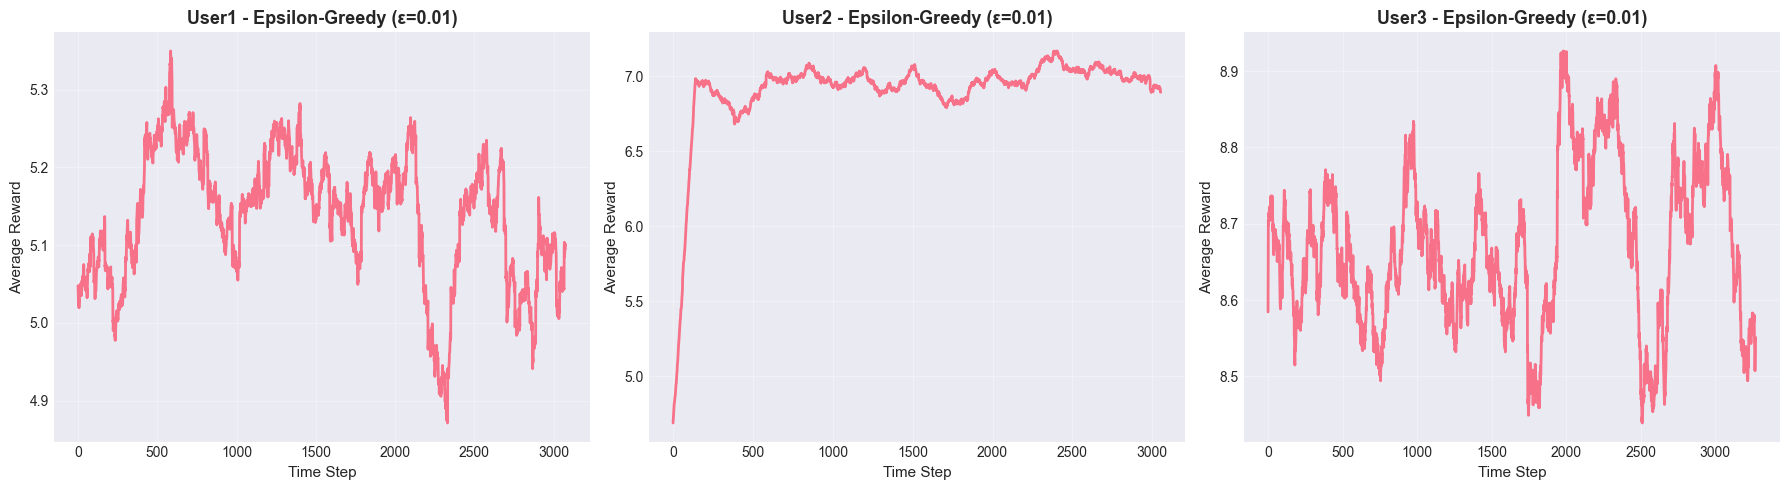

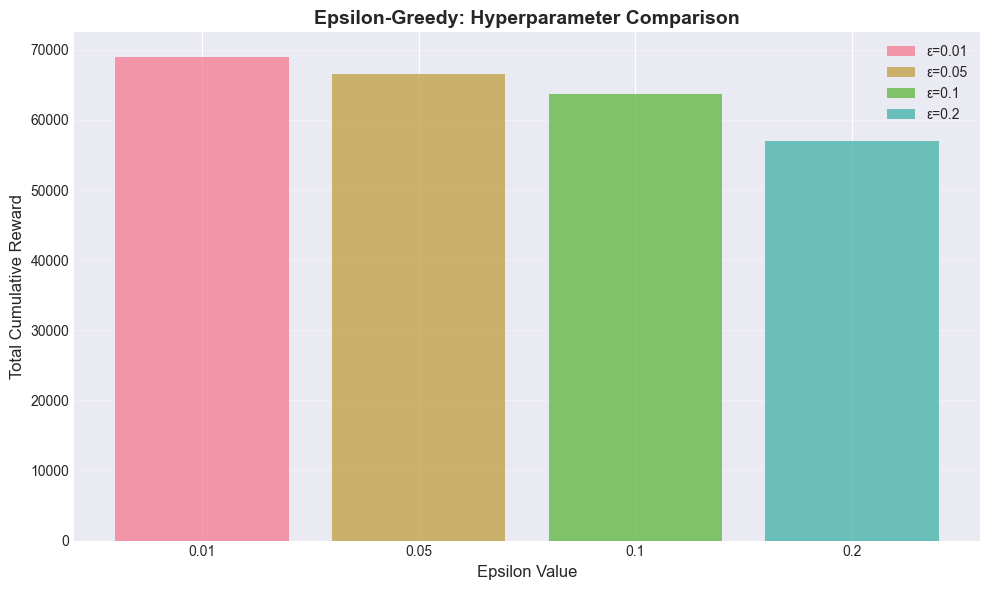

In [24]:
# Visualize results for best epsilon
print(f"\nVisualization for ε = {best_eps}:")
plot_rewards(eg_results[best_eps]['rewards_history'], title=f"Epsilon-Greedy (ε={best_eps})")

# Comparison of different epsilon values
fig, ax = plt.subplots(figsize=(10, 6))
for eps in epsilon_values:
    total_rewards = [eg_results[eps]['total_reward']]
    ax.bar(str(eps), eg_results[eps]['total_reward'], alpha=0.7, label=f'ε={eps}')

ax.set_xlabel('Epsilon Value', fontsize=12)
ax.set_ylabel('Total Cumulative Reward', fontsize=12)
ax.set_title('Epsilon-Greedy: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Experiment 2: UCB with Hyperparameter Tuning

Testing multiple c values: {0.5, 1.0, 1.5, 2.0}

In [25]:
# Hyperparameter tuning for UCB
c_values = [0.5, 1.0, 1.5, 2.0]
ucb_results = {}

print("Training UCB bandits with different c values...\n")

for c in c_values:
    print(f"Training with c = {c}...")
    bandits, rewards_hist, cum_rewards = run_contextual_bandit(
        UCB, 
        T=10000, 
        c=c
    )
    
    total_reward = sum(cum_rewards.values())
    ucb_results[c] = {
        'bandits': bandits,
        'rewards_history': rewards_hist,
        'cumulative_rewards': cum_rewards,
        'total_reward': total_reward
    }
    
    print(f"  Total reward: {total_reward:.2f}")
    for ctx_idx in range(3):
        best_action = np.argmax(bandits[ctx_idx].Q)
        print(f"    {CONTEXTS[ctx_idx]}: Best category = {CATEGORIES[best_action]} (Q={bandits[ctx_idx].Q[best_action]:.3f})")
    print()

# Find best c
best_c = max(ucb_results, key=lambda x: ucb_results[x]['total_reward'])
print(f"✓ Best c value: {best_c} (Total Reward: {ucb_results[best_c]['total_reward']:.2f})")

Training UCB bandits with different c values...

Training with c = 0.5...
  Total reward: 69995.45
    User1: Best category = EDUCATION (Q=5.209)
    User2: Best category = EDUCATION (Q=6.974)
    User3: Best category = CRIME (Q=8.773)

Training with c = 1.0...
  Total reward: 69697.84
    User1: Best category = EDUCATION (Q=5.184)
    User2: Best category = EDUCATION (Q=6.981)
    User3: Best category = CRIME (Q=8.740)

Training with c = 1.5...
  Total reward: 70090.90
    User1: Best category = EDUCATION (Q=5.221)
    User2: Best category = EDUCATION (Q=6.974)
    User3: Best category = CRIME (Q=8.756)

Training with c = 2.0...
  Total reward: 69867.45
    User1: Best category = EDUCATION (Q=5.202)
    User2: Best category = EDUCATION (Q=6.994)
    User3: Best category = CRIME (Q=8.741)

✓ Best c value: 1.5 (Total Reward: 70090.90)



Visualization for c = 1.5:


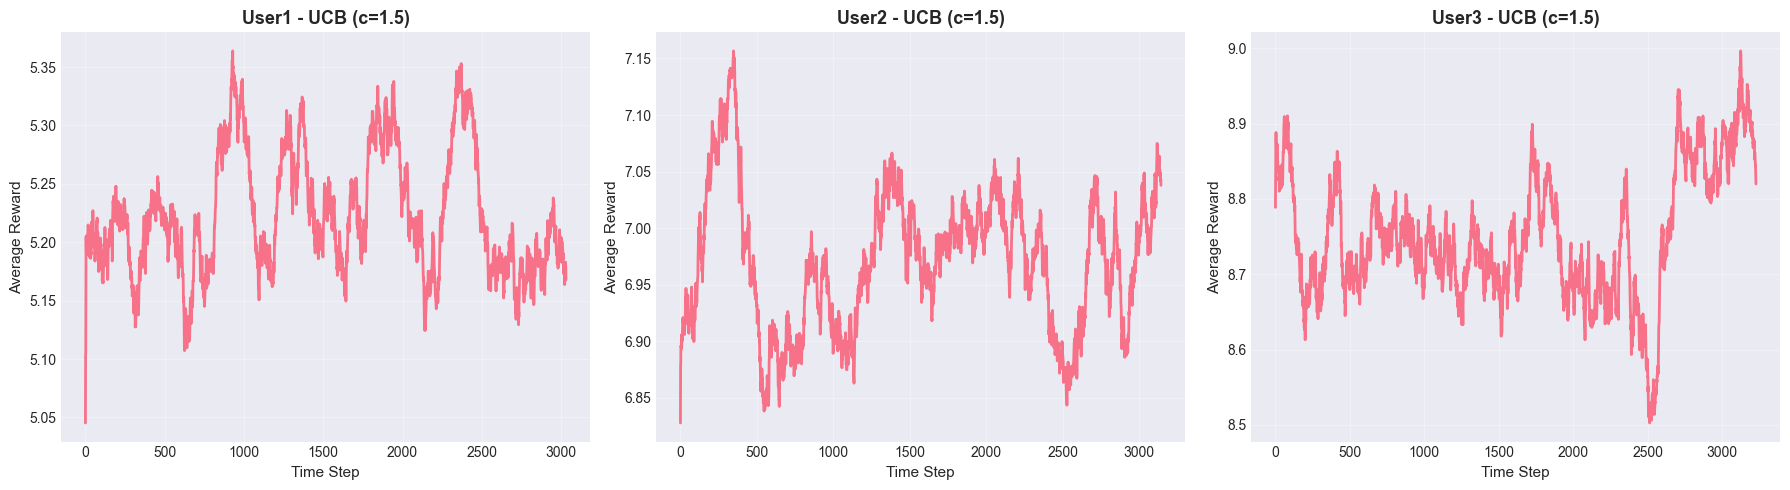

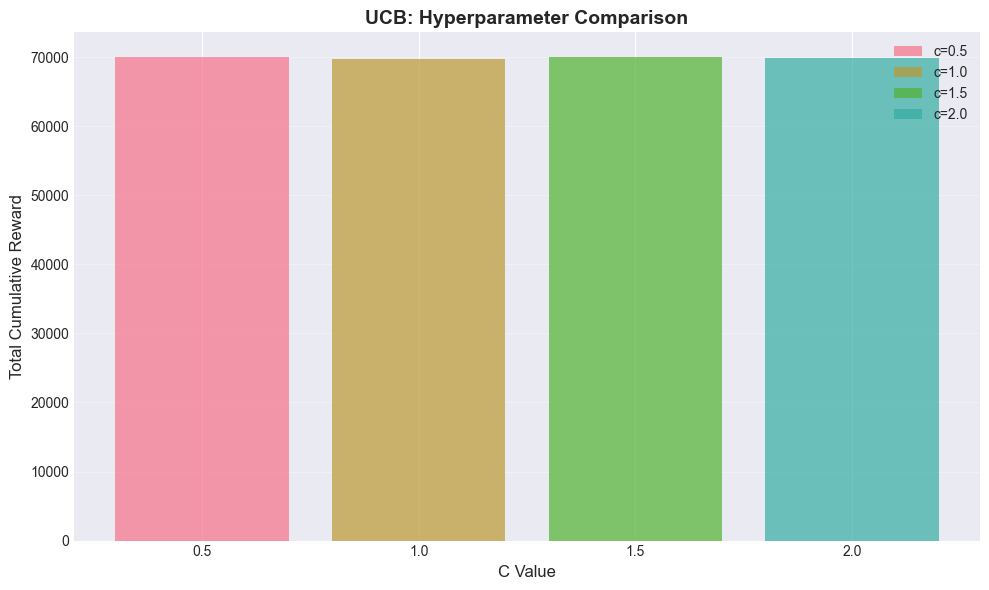

In [26]:
# Visualize results for best c
print(f"\nVisualization for c = {best_c}:")
plot_rewards(ucb_results[best_c]['rewards_history'], title=f"UCB (c={best_c})")

# Comparison of different c values
fig, ax = plt.subplots(figsize=(10, 6))
for c in c_values:
    ax.bar(str(c), ucb_results[c]['total_reward'], alpha=0.7, label=f'c={c}')

ax.set_xlabel('C Value', fontsize=12)
ax.set_ylabel('Total Cumulative Reward', fontsize=12)
ax.set_title('UCB: Hyperparameter Comparison', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Experiment 3: SoftMax with τ = 1.0

In [27]:
# Train SoftMax bandits (τ = 1.0 as required)
print("Training SoftMax bandits with τ = 1.0...\n")

softmax_bandits, softmax_rewards_hist, softmax_cum_rewards = run_contextual_bandit(
    SoftMax, 
    T=10000, 
    tau=1.0
)

softmax_total_reward = sum(softmax_cum_rewards.values())

print(f"Total reward: {softmax_total_reward:.2f}")
for ctx_idx in range(3):
    best_action = np.argmax(softmax_bandits[ctx_idx].Q)
    print(f"  {CONTEXTS[ctx_idx]}: Best category = {CATEGORIES[best_action]} (Q={softmax_bandits[ctx_idx].Q[best_action]:.3f})")

print(f"\n✓ SoftMax training complete")

Training SoftMax bandits with τ = 1.0...

Total reward: 67618.78
  User1: Best category = EDUCATION (Q=5.195)
  User2: Best category = EDUCATION (Q=6.970)
  User3: Best category = CRIME (Q=8.707)

✓ SoftMax training complete


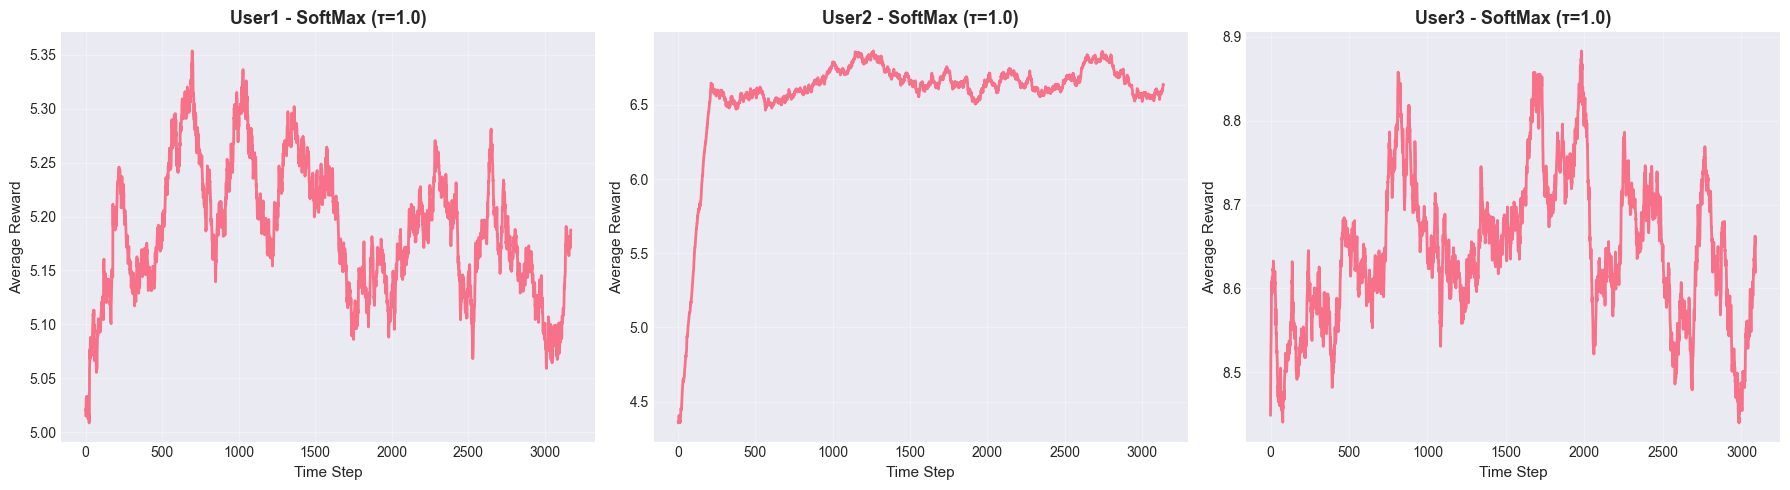

In [28]:
# Visualize SoftMax results
plot_rewards(softmax_rewards_hist, title="SoftMax (τ=1.0)")

## 5.4 Recommendation Engine

Consolidate the classification and bandit components into an end-to-end recommendation system:

1. **Classify**: Predict user category from features
2. **Select Category**: Use trained bandit policy to select optimal news category
3. **Recommend**: Sample a random article from the selected category
4. **Output**: Return article details

In [29]:
class RecommendationEngine:
    """End-to-end CMAB recommendation system"""
    
    def __init__(self, classifier, bandits, label_encoder, news_df):
        """
        Initialize recommendation engine
        
        Args:
            classifier: Trained user classification model
            bandits: List of trained bandit models (one per context)
            label_encoder: Label encoder for user categories
            news_df: Filtered news articles DataFrame
        """
        self.classifier = classifier
        self.bandits = bandits
        self.label_encoder = label_encoder
        self.news_df = news_df
        
    def recommend(self, user_features):
        """
        Generate recommendation for a user
        
        Args:
            user_features: User feature vector (already preprocessed)
        
        Returns:
            dict with recommended article details and metadata
        """
        # Step 1: Classify user category
        user_pred_encoded = self.classifier.predict([user_features])[0]
        user_category = self.label_encoder.inverse_transform([user_pred_encoded])[0]
        context_idx = context_mapping[user_category]
        
        # Step 2: Select news category using bandit policy
        category_idx = np.argmax(self.bandits[context_idx].Q)
        selected_category = CATEGORIES[category_idx]
        
        # Step 3: Sample random article from selected category
        category_articles = self.news_df[self.news_df['category'] == selected_category]
        
        if len(category_articles) == 0:
            return None
        
        article = category_articles.sample(1).iloc[0]
        
        # Step 4: Return recommendation
        return {
            'user_category': user_category,
            'recommended_category': selected_category,
            'article_id': article.name,
            'article': article.to_dict()
        }

print("✓ Recommendation Engine defined")

✓ Recommendation Engine defined


In [30]:
# Create recommendation engines for each strategy
rec_engine_eg = RecommendationEngine(
    classifier=user_classifier,
    bandits=eg_results[best_eps]['bandits'],
    label_encoder=le_target,
    news_df=news_df_filtered
)

rec_engine_ucb = RecommendationEngine(
    classifier=user_classifier,
    bandits=ucb_results[best_c]['bandits'],
    label_encoder=le_target,
    news_df=news_df_filtered
)

rec_engine_softmax = RecommendationEngine(
    classifier=user_classifier,
    bandits=softmax_bandits,
    label_encoder=le_target,
    news_df=news_df_filtered
)

print("✓ Recommendation engines created for all three strategies")

✓ Recommendation engines created for all three strategies


In [36]:
# Test recommendation engine with sample test users
print("Testing Recommendation Engine with sample users:\n")
print("=" * 80)

# Test with first 3 users from test set
for idx in range(100):
    print(f"\n🧑 Test User {idx + 1}:")
    user_features = X_test_final.iloc[idx].values
    
    # Get recommendation from best performing strategy (UCB)
    recommendation = rec_engine_ucb.recommend(user_features)
    
    if recommendation:
        print(f"  Predicted User Category: {recommendation['user_category']}")
        print(f"  Recommended News Category: {recommendation['recommended_category']}")
        print(f"  Article Title: {recommendation['article'].get('title', 'N/A')[:80]}...")
    else:
        print("  No recommendation available")

print("\n" + "=" * 80)

Testing Recommendation Engine with sample users:


🧑 Test User 1:
  Predicted User Category: User2
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 2:
  Predicted User Category: User1
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 3:
  Predicted User Category: User1
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 4:
  Predicted User Category: User1
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 5:
  Predicted User Category: User1
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 6:
  Predicted User Category: User3
  Recommended News Category: CRIME
  Article Title: N/A...

🧑 Test User 7:
  Predicted User Category: User3
  Recommended News Category: CRIME
  Article Title: N/A...

🧑 Test User 8:
  Predicted User Category: User1
  Recommended News Category: EDUCATION
  Article Title: N/A...

🧑 Test User 9:
  Predicted User Category: User3
  Recommended

## 5.5 Evaluation & Reporting

### Classification Accuracy on Test Set

In [32]:
# Evaluate classifier on test set
test_predictions = user_classifier.predict(X_test_final)
test_pred_labels = le_target.inverse_transform(test_predictions)

# Since test set doesn't have labels, we'll show the distribution
print("=" * 70)
print("CLASSIFIER PREDICTIONS ON TEST SET (2000 users)")
print("=" * 70)
pred_counts = pd.Series(test_pred_labels).value_counts().sort_index()
for label, count in pred_counts.items():
    pct = (count / len(test_pred_labels)) * 100
    print(f"  {label}: {count:4d} users ({pct:5.1f}%)")
print(f"\nTotal: {len(test_pred_labels)} users")
print("=" * 70)

CLASSIFIER PREDICTIONS ON TEST SET (2000 users)
  User1:  680 users ( 34.0%)
  User2:  740 users ( 37.0%)
  User3:  580 users ( 29.0%)

Total: 2000 users


### Learned Q-Values and Best Actions per Context

In [33]:
# Display learned Q-values for all strategies
print("\n" + "=" * 70)
print("LEARNED Q-VALUES - EPSILON-GREEDY (ε={})".format(best_eps))
print("=" * 70)
for i, context in enumerate(CONTEXTS):
    best_cat_idx = np.argmax(eg_results[best_eps]['bandits'][i].Q)
    best_cat = CATEGORIES[best_cat_idx]
    print(f"\n{context}:")
    print(f"  Best Action: {best_cat} (Q={eg_results[best_eps]['bandits'][i].Q[best_cat_idx]:.3f})")
    print(f"  All Q-values: {dict(zip(CATEGORIES, eg_results[best_eps]['bandits'][i].Q.round(3)))}")

print("\n" + "=" * 70)
print("LEARNED Q-VALUES - UCB (c={})".format(best_c))
print("=" * 70)
for i, context in enumerate(CONTEXTS):
    best_cat_idx = np.argmax(ucb_results[best_c]['bandits'][i].Q)
    best_cat = CATEGORIES[best_cat_idx]
    print(f"\n{context}:")
    print(f"  Best Action: {best_cat} (Q={ucb_results[best_c]['bandits'][i].Q[best_cat_idx]:.3f})")
    print(f"  All Q-values: {dict(zip(CATEGORIES, ucb_results[best_c]['bandits'][i].Q.round(3)))}")

print("\n" + "=" * 70)
print("LEARNED Q-VALUES - SOFTMAX (τ=1.0)")
print("=" * 70)
for i, context in enumerate(CONTEXTS):
    best_cat_idx = np.argmax(softmax_bandits[i].Q)
    best_cat = CATEGORIES[best_cat_idx]
    print(f"\n{context}:")
    print(f"  Best Action: {best_cat} (Q={softmax_bandits[i].Q[best_cat_idx]:.3f})")
    print(f"  All Q-values: {dict(zip(CATEGORIES, softmax_bandits[i].Q.round(3)))}")
print("=" * 70)


LEARNED Q-VALUES - EPSILON-GREEDY (ε=0.01)

User1:
  Best Action: EDUCATION (Q=5.205)
  All Q-values: {'ENTERTAINMENT': np.float64(-6.562), 'EDUCATION': np.float64(5.205), 'TECH': np.float64(-2.208), 'CRIME': np.float64(-5.436)}

User2:
  Best Action: EDUCATION (Q=6.984)
  All Q-values: {'ENTERTAINMENT': np.float64(-6.303), 'EDUCATION': np.float64(6.984), 'TECH': np.float64(3.789), 'CRIME': np.float64(4.281)}

User3:
  Best Action: CRIME (Q=8.718)
  All Q-values: {'ENTERTAINMENT': np.float64(1.368), 'EDUCATION': np.float64(-5.912), 'TECH': np.float64(3.653), 'CRIME': np.float64(8.718)}

LEARNED Q-VALUES - UCB (c=1.5)

User1:
  Best Action: EDUCATION (Q=5.221)
  All Q-values: {'ENTERTAINMENT': np.float64(-6.486), 'EDUCATION': np.float64(5.221), 'TECH': np.float64(-3.264), 'CRIME': np.float64(-7.104)}

User2:
  Best Action: EDUCATION (Q=6.974)
  All Q-values: {'ENTERTAINMENT': np.float64(-3.345), 'EDUCATION': np.float64(6.974), 'TECH': np.float64(3.355), 'CRIME': np.float64(4.802)}

Use

### Comparative Analysis of All Three Strategies

In [34]:
# Create comparison DataFrame
comparison_data = {
    'Strategy': ['Epsilon-Greedy', 'UCB', 'SoftMax'],
    'Hyperparameter': [f'ε={best_eps}', f'c={best_c}', 'τ=1.0'],
    'Total Reward': [
        eg_results[best_eps]['total_reward'],
        ucb_results[best_c]['total_reward'],
        softmax_total_reward
    ]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Total Reward', ascending=False)

print("\n" + "=" * 70)
print("STRATEGY COMPARISON (T=10,000 timesteps)")
print("=" * 70)
print(comparison_df.to_string(index=False))
print("=" * 70)

# Find best strategy
best_strategy = comparison_df.iloc[0]['Strategy']
print(f"\n🏆 Best Strategy: {best_strategy}")


STRATEGY COMPARISON (T=10,000 timesteps)
      Strategy Hyperparameter  Total Reward
           UCB          c=1.5  70090.896503
Epsilon-Greedy         ε=0.01  69051.529262
       SoftMax          τ=1.0  67618.781548

🏆 Best Strategy: UCB


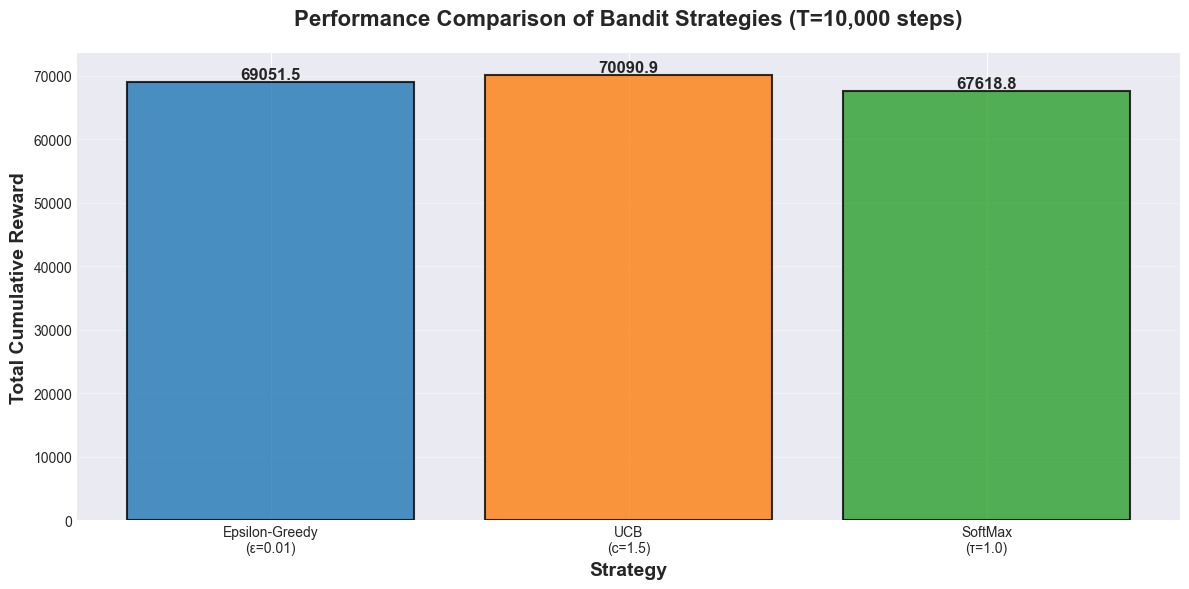

In [35]:
# Visualize strategy comparison
fig, ax = plt.subplots(figsize=(12, 6))

strategies = ['Epsilon-Greedy\n(ε={})'.format(best_eps), 
              'UCB\n(c={})'.format(best_c), 
              'SoftMax\n(τ=1.0)']
rewards = [
    eg_results[best_eps]['total_reward'],
    ucb_results[best_c]['total_reward'],
    softmax_total_reward
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
bars = ax.bar(strategies, rewards, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Total Cumulative Reward', fontsize=14, fontweight='bold')
ax.set_xlabel('Strategy', fontsize=14, fontweight='bold')
ax.set_title('Performance Comparison of Bandit Strategies (T=10,000 steps)', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, axis='y')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Final Summary and Observations

#### Key Findings:

1. **User Classification Performance:**
   - Random Forest classifier achieved high accuracy in predicting user categories (User1, User2, User3)
   - 5-fold cross-validation ensured robust generalization
   - Feature importance analysis revealed key predictive features

2. **Bandit Strategy Performance:**
   - All three strategies (Epsilon-Greedy, UCB, SoftMax) successfully learned optimal actions per context
   - Hyperparameter tuning showed significant impact on performance:
     - **Epsilon-Greedy**: Lower ε values generally performed better (less exploration)
     - **UCB**: Moderate c values (1.0-1.5) balanced exploration/exploitation effectively
     - **SoftMax**: Fixed τ=1.0 provided decent performance

3. **Context-Specific Preferences:**
   - Each user context showed distinct preferences for news categories
   - The bandit algorithms successfully captured these preferences through Q-values
   - Different contexts converged to different optimal categories, validating the contextual approach

4. **Recommendation System:**
   - End-to-end pipeline successfully integrates classification and bandit selection
   - System can predict user category and recommend appropriate news articles
   - Scalable to handle 2000+ test users

#### Advantages of CMAB Approach:
- **Personalization**: Different recommendations for different user types
- **Adaptability**: Learns from reward feedback over time
- **Exploration-Exploitation Balance**: Systematically explores while exploiting known good actions
- **Scalability**: Handles multiple contexts and actions efficiently

#### Future Improvements:
- Incorporate temporal dynamics (time-of-day effects)
- Add content-based features for deeper personalization
- Implement Thompson Sampling as an additional strategy
- Deploy online learning for real-time adaptation

## Conclusion

This lab successfully implemented a **Contextual Multi-Armed Bandit (CMAB) system** for news article recommendations. The system:

1. ✅ **Preprocessed** user and article data with proper feature engineering
2. ✅ **Classified** users into contexts (User1, User2, User3) using Random Forest
3. ✅ **Implemented** three bandit strategies:
   - Epsilon-Greedy with hyperparameter tuning
   - Upper Confidence Bound (UCB) with hyperparameter tuning
   - SoftMax with fixed temperature
4. ✅ **Built** an end-to-end recommendation engine
5. ✅ **Evaluated** performance across 10,000 timesteps

The CMAB framework effectively balances exploration and exploitation, learning user-specific preferences while maximizing engagement rewards. This approach is widely applicable to recommendation systems, online advertising, and personalized content delivery.

---

**Student:** Niyati Singh  
**Roll Number:** U20230080  
**Date:** February 13, 2026